In [286]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from numpy.core.numeric import NaN

warnings.filterwarnings("ignore")

In [287]:

tickers = ['CESC.NS', 'SAREGAMA.NS', 'FSL.NS', 'PCBL.NS', 'RPSGVENT.NS']

df = yf.download(tickers, start="2019-06-06",end= '2026-01-01',auto_adjust=False,multi_level_index=False)['Adj Close']


df['Cesc'] = np.log(df['CESC.NS']/df['CESC.NS'].shift(1))
df['Fsl'] = np.log(df['FSL.NS']/df['FSL.NS'].shift(1))
df['Pcbl'] = np.log(df['PCBL.NS']/df['PCBL.NS'].shift(1))
df['Rpsgvent'] = np.log(df['RPSGVENT.NS']/df['RPSGVENT.NS'].shift(1))
df['Saregama'] = np.log(df['SAREGAMA.NS']/df['SAREGAMA.NS'].shift(1))
df = df[['Cesc','Fsl','Pcbl','Rpsgvent','Saregama']]
df.dropna(inplace=True)

df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

x = df.drop(columns=['Rpsgvent'])
y = df['Rpsgvent']

x.corr()

[*********************100%***********************]  5 of 5 completed


Ticker,Cesc,Fsl,Pcbl,Saregama
Ticker,,,,
Cesc,1.000000,0.327772,0.351667,0.178815
Fsl,0.327772,1.000000,0.341178,0.192417
Pcbl,0.351667,0.341178,1.000000,0.224780
Saregama,0.178815,0.192417,0.224780,1.000000


In [288]:
from sklearn.linear_model import LinearRegression
window = 50
pred = []
coef = []
dates = []

for i in range(window,len(df)):

    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    x_test = x.iloc[i:i+1]

    model = LinearRegression().fit(x_train, y_train)

    prediction = model.predict(x_test)[0]
    pred.append(prediction)
    coef.append(model.coef_)
    dates.append(x_test.index[0])

results = pd.DataFrame({'Date': dates,'Prediction': pred})

results.set_index('Date', inplace=True)
results['Actual'] = y.loc[results.index]
results['Residual'] = results['Actual'] - results['Prediction']

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(results['Actual'], results['Prediction'])
mae = mean_absolute_error( results['Actual'],results['Prediction'])
rmse = np.sqrt(mse)
r2 = r2_score(results['Actual'],results['Prediction'])

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)


MAE:  0.01894101688001014
MSE:  0.0007316253622445907
RMSE:  0.027048574125905247
R2:  0.20688521294802265


# Residual Analysis

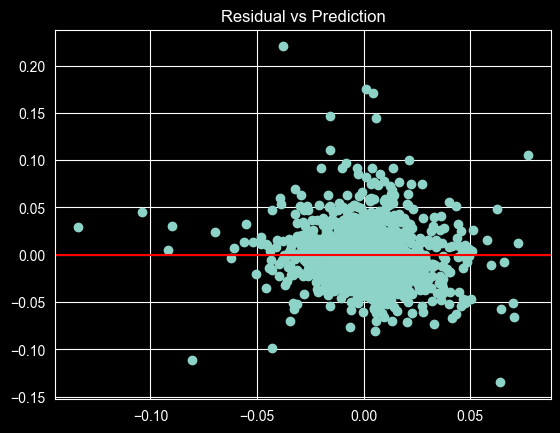

In [289]:
# Residual vs Prediciton Scatter Model
plt.scatter(results['Prediction'], results['Residual'])
plt.axhline(0, color='red')
plt.title("Residual vs Prediction")
plt.show()


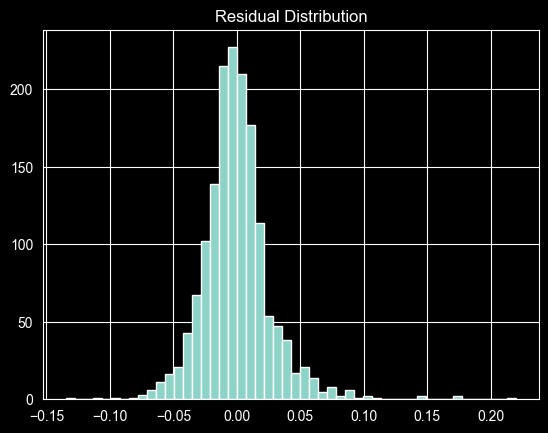

In [290]:
results['Residual'].hist(bins=50)
plt.title("Residual Distribution")
plt.show()

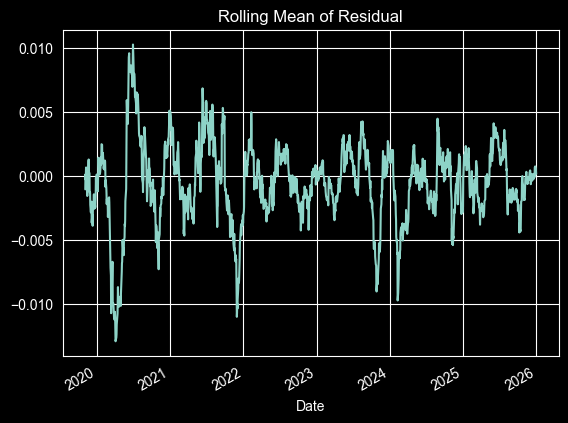

In [291]:
results['Residual'].rolling(50).mean().plot(title="Rolling Mean of Residual")
plt.show()

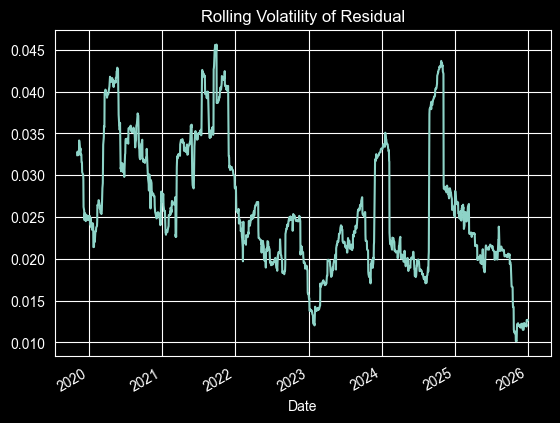

In [292]:
results['Residual'].rolling(50).std().plot(title="Rolling Volatility of Residual")
plt.show()

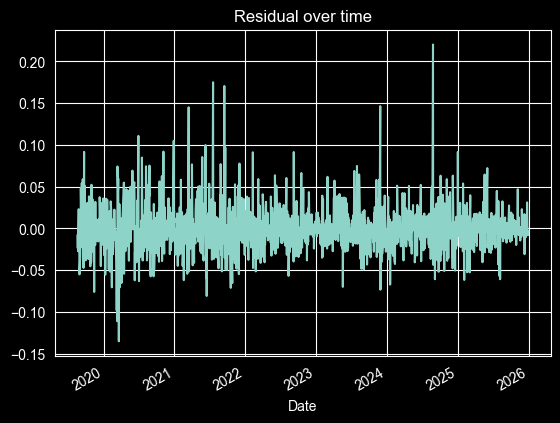

In [293]:
results['Residual'].plot(title="Residual over time")
plt.show()

In [294]:
print("Autocorrelation:", results['Residual'].autocorr())

Autocorrelation: -0.00996623054759033


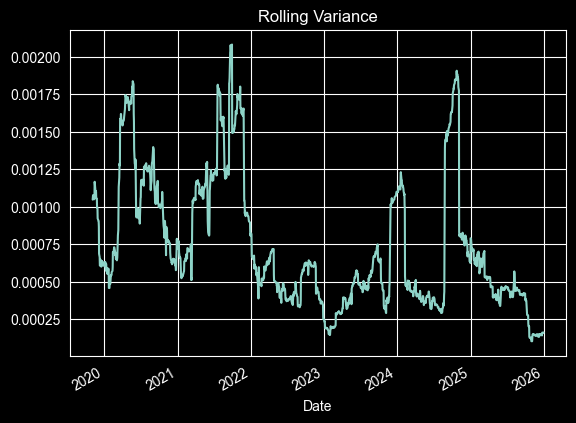

In [295]:
results['Residual'].rolling(50).var().plot(title="Rolling Variance")
plt.show()

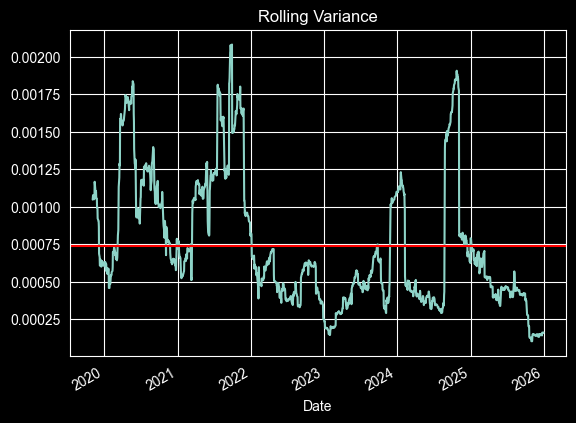

In [296]:
rolling_var = results['Residual'].rolling(50).var()

rolling_var.plot(title="Rolling Variance")
plt.axhline(rolling_var.mean(), color='red')
plt.show()